
# Walmart Global Model Sanity Check

이 notebook의 목적은 하나입니다.

`patchtst_exo`, `timexer`, `exotst` 같은 **global model family 자체가 구조적으로 문제인지**, 아니면
현재 DSIO 부품 데이터의 `small / erratic / high-obsolescence / decline` 세그먼트가 문제인지 분리해서 보는 것입니다.

검증 논리는 단순합니다.
- Walmart처럼 비교적 dense하고 규칙적인 weekly retail 데이터에서도
  글로벌 모델이 비슷하게 심한 overforecast / underforecast를 만들면 모델/학습 파이프라인 문제일 가능성이 큽니다.
- 반대로 Walmart에서는 aggregate scale과 part-level shape가 비교적 정상적이면,
  현재 DSIO 문제는 모델 family 자체보다 **데이터 세그먼트 특성** 쪽일 가능성이 높습니다.

권장 실행 순서:
1. Setup / Config
2. Data Preparation
3. Loader Smoke Test
4. Train + Forecast
5. Metrics / Plots
6. Interpretation Guide


In [1]:

from __future__ import annotations

%load_ext autoreload
%autoreload 2

import argparse
import importlib.util
import os
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
from IPython.display import Image, display

REPO_ROOT_OVERRIDE = None


def _looks_like_repo(path: Path) -> bool:
    return (path / 'pyproject.toml').exists() and (path / 'src').exists()


def _iter_named_repo_candidates(root: Path, repo_name: str = 'ts_forecaster_lib', max_depth: int = 4):
    if not root.exists() or not root.is_dir():
        return
    try:
        root_resolved = root.resolve()
    except Exception:
        root_resolved = root
    stack = [(root_resolved, 0)]
    while stack:
        current, depth = stack.pop()
        if current.name == repo_name:
            yield current
        if depth >= max_depth:
            continue
        try:
            children = list(current.iterdir())
        except Exception:
            continue
        for child in children:
            if child.is_dir() and not child.name.startswith('.'):
                stack.append((child, depth + 1))


def find_repo_root(start: Path, explicit_repo_root: Path | None = None) -> Path | None:
    env_repo_root = os.environ.get('TS_FORECASTER_REPO_ROOT')
    candidates = []
    if explicit_repo_root is not None:
        candidates.append(Path(explicit_repo_root).expanduser().resolve())
    if env_repo_root:
        candidates.append(Path(env_repo_root).expanduser().resolve())
    candidates.extend([start, *start.parents])

    home = Path.home()
    common_roots = [
        home,
        home / 'workspace',
        home / 'workspaces',
        home / 'projects',
        home / 'PycharmProjects',
        Path('/workspace'),
        Path('/workspaces'),
        Path('/home'),
        Path('/root'),
    ]
    for root in common_roots:
        candidates.extend(_iter_named_repo_candidates(root))

    seen = set()
    for candidate in candidates:
        if candidate in seen:
            continue
        seen.add(candidate)
        if _looks_like_repo(candidate):
            return candidate
    return None


def resolve_import_paths() -> tuple[Path | None, Path | None]:
    repo_root = find_repo_root(Path.cwd().resolve(), explicit_repo_root=REPO_ROOT_OVERRIDE)
    src_root = repo_root / 'src' if repo_root is not None else None
    if src_root is not None and str(src_root) not in sys.path:
        sys.path.insert(0, str(src_root))

    spec = importlib.util.find_spec('modeling_module')
    if spec is None or spec.origin is None:
        raise RuntimeError(
            'Could not import modeling_module. Set REPO_ROOT_OVERRIDE, TS_FORECASTER_REPO_ROOT, or install the package.'
        )

    module_init = Path(spec.origin).resolve()
    module_root = module_init.parent
    if repo_root is None and module_root.parent.name == 'src':
        repo_root = module_root.parent.parent
        src_root = repo_root / 'src'
    return repo_root, src_root


NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT, SRC_ROOT = resolve_import_paths()

from modeling_module import (
    ArtifactConfig,
    DataColumnConfig,
    DataRequest,
    DataWindowConfig,
    ExogenousConfig,
    LoaderConfig,
    RuntimeConfig,
    SSLConfig,
    TrainRequest,
    TrainerConfig,
)
from modeling_module.api.data import build_datamodule
from modeling_module.api.infer import load_predictor
from modeling_module.api.train import train
from model_test.exogenous_test.exogenous_ab_utils import (
    attach_actuals,
    compute_metric_tables,
    ensure_dir,
    make_point_forecast_result_table,
    plot_latest_revision_aggregate,
    plot_latest_revision_part_grid,
    plot_metric_summary,
    resolve_single_plan_week,
    select_eval_ids_with_full_actual_coverage,
    select_latest_revision,
    select_plot_parts,
)
from model_test.exogenous_test.run_exogenous_model_ab import (
    ModelSpec,
    build_architecture_config,
)

WALMART_MODEL_SPECS: dict[str, ModelSpec] = {
    'patchtst_no_future': ModelSpec(label='patchtst_no_future', request_key='patchtst_base', use_future_exogenous=False),
    'timexer': ModelSpec(label='timexer', request_key='timexer_base', use_future_exogenous=False),
    'exotst': ModelSpec(label='exotst', request_key='exotst_base', use_future_exogenous=True),
}


def resolve_walmart_model_specs(names: list[str]) -> list[ModelSpec]:
    out: list[ModelSpec] = []
    for name in names:
        key = str(name).strip().lower()
        if key not in WALMART_MODEL_SPECS:
            raise ValueError(f'Unsupported Walmart model name: {name}. Expected one of {sorted(WALMART_MODEL_SPECS)}')
        out.append(WALMART_MODEL_SPECS[key])
    return out


def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def configure_torch_runtime() -> tuple[str, str | None]:
    if torch.cuda.is_available():
        torch.set_float32_matmul_precision('high')
        return 'cuda', None
    if torch.backends.mps.is_available():
        return 'mps', 'CUDA not available, using Apple MPS.'
    return 'cpu', 'CUDA/MPS not available, using CPU.'



## Config

이 notebook은 Walmart weekly dense dataset에서 **global model sanity check**를 수행합니다.

기본 해석 기준:
- `pred_to_actual_ratio`가 1 근처면 total scale이 비교적 정상
- aggregate plot이 GT shape를 비슷하게 따라가면 global model family 자체 문제 가능성은 낮음
- 여기서도 DSIO와 비슷하게 강한 overforecast가 반복되면 모델/학습 파이프라인을 더 의심해야 함


In [2]:

artifact_root = REPO_ROOT / 'artifacts' / 'exogenous_test' / 'walmart_global_sanity'
ensure_dir(artifact_root)

PARQUET_PATH = REPO_ROOT / 'raw_data' / 'train_data' / 'walmart_best_feature_train.parquet'

models_to_run = ['patchtst_no_future', 'timexer', 'exotst']

lookback = 52
horizon = 13
plan_week = 201231
plot_part_count = 12
max_parts_per_plan = 10_000

train_batch_size = 128
infer_batch_size = 64
num_workers = 0
pin_memory = False
persistent_workers = False
prefetch_factor = 2
seed = 22

warmup_epochs = 30
spike_epochs = 5
lr = 1e-3
ssl_mode = 'sl_only'
ssl_pretrain_epochs = 0
ssl_mask_ratio = 0.3
ssl_loss_type = 'mse'

# Walmart sanity check에서는 dense/continuous data에 맞춰 보수적인 설정으로 시작합니다.
use_intermittent = False
val_use_weights = False

set_global_seed(seed)
default_device, device_note = configure_torch_runtime()
device = default_device
effective_patchtst_ssl_mode = ssl_mode if (str(ssl_mode).lower() != 'sl_only' and int(ssl_pretrain_epochs) > 0) else 'sl_only'

print('PARQUET_PATH      :', PARQUET_PATH)
print('models_to_run     :', models_to_run)
print('lookback / horizon:', lookback, horizon)
print('plan_week         :', plan_week)
print('device            :', device)
print('ssl_mode(requested):', ssl_mode)
print('ssl_mode(effective):', effective_patchtst_ssl_mode)
print('ssl_pretrain_epochs:', ssl_pretrain_epochs)
print('use_intermittent  :', use_intermittent)
print('val_use_weights   :', val_use_weights)
if device_note:
    print('device_note       :', device_note)


PARQUET_PATH      : /home/leekwanhyeong/workspace/ts_forecaster_lib/raw_data/train_data/walmart_best_feature_train.parquet
models_to_run     : ['patchtst_no_future', 'timexer', 'exotst']
lookback / horizon: 52 13
plan_week         : 201231
device            : cuda
ssl_mode(requested): sl_only
ssl_mode(effective): sl_only
ssl_pretrain_epochs: 0
use_intermittent  : False
val_use_weights   : False



## Data Preparation

Walmart parquet은 이미 best feature train table 형태이므로,
이 notebook에서는 별도의 lifecycle 가공 없이 바로 global model 검증에 사용합니다.

컬럼 사용 규칙:
- `y`: target
- `exo_p_*`: past exogenous
- `exo_*` but not `exo_p_*`, `exo_c_*`: future-known continuous exogenous
- `exo_c_*`: 원래는 categorical 후보지만, 이 sanity check에서는 cardinality/indexer 의존성을 줄이기 위해 **continuous로 흡수**합니다.


In [3]:

ID_COL = 'unique_id'
DATE_COL = 'date'
Y_COL = 'y'
FREQ = 'weekly'

df = (
    pl.read_parquet(PARQUET_PATH)
    .with_columns([
        pl.col(ID_COL).cast(pl.String),
        pl.col(DATE_COL).cast(pl.Int64),
        pl.col(Y_COL).cast(pl.Float64),
        *[pl.col(c).cast(pl.Float64) for c in pl.read_parquet(PARQUET_PATH, n_rows=1).columns if c.startswith('exo_c_')],
    ])
    .sort([ID_COL, DATE_COL])
)

target_df = df.select([ID_COL, DATE_COL, Y_COL])

past_exo_cont_cols = [c for c in df.columns if c.startswith('exo_p_')] + [c for c in df.columns if c.startswith('exo_c_')]
past_exo_cat_cols = []
future_exo_cont_cols = [
    c for c in df.columns
    if c.startswith('exo_') and not c.startswith('exo_p_') and not c.startswith('exo_c_')
]

plan_week = resolve_single_plan_week(
    target_df,
    date_col=DATE_COL,
    horizon=horizon,
    plan_week=plan_week,
)

eval_ids = select_eval_ids_with_full_actual_coverage(
    target_df,
    id_col=ID_COL,
    date_col=DATE_COL,
    plan_weeks=[plan_week],
    horizon=horizon,
)

eval_target_df = target_df.filter(pl.col(ID_COL).cast(pl.String).is_in(eval_ids))
train_one_table = df.filter(pl.col(DATE_COL) < int(plan_week))
infer_one_table = df.filter(pl.col(ID_COL).cast(pl.String).is_in(eval_ids))

print('df shape             :', df.shape)
print('target_df shape      :', target_df.shape)
print('train_one_table      :', train_one_table.shape)
print('infer_one_table      :', infer_one_table.shape)
print('eval_target_df       :', eval_target_df.shape)
print('eval_id_count        :', len(eval_ids))
print('plan_week            :', plan_week)
print('past_exo_cont_cols   :', len(past_exo_cont_cols), past_exo_cont_cols)
print('past_exo_cat_cols    :', len(past_exo_cat_cols), past_exo_cat_cols)
print('future_exo_cont_cols :', len(future_exo_cont_cols), future_exo_cont_cols)
print('date min/max         :', int(df[DATE_COL].min()), int(df[DATE_COL].max()))


df shape             : (6435, 38)
target_df shape      : (6435, 3)
train_one_table      : (5850, 38)
infer_one_table      : (6435, 38)
eval_target_df       : (6435, 3)
eval_id_count        : 45
plan_week            : 201231
past_exo_cont_cols   : 18 ['exo_p_y_lag_1w', 'exo_p_y_lag_2w', 'exo_p_y_lag_52w', 'exo_p_y_rollmean_4w', 'exo_p_y_rollmean_12w', 'exo_p_y_rollstd_4w', 'exo_p_weeks_since_holiday', 'exo_p_temperature', 'exo_p_fuel_price', 'exo_p_cpi', 'exo_p_unemployment', 'exo_p_markdown_sum', 'exo_p_markdown1', 'exo_p_markdown2', 'exo_p_markdown3', 'exo_p_markdown4', 'exo_p_markdown5', 'exo_c_woy_bucket']
past_exo_cat_cols    : 0 []
future_exo_cont_cols : 16 ['exo_is_holiday', 'exo_temperature', 'exo_fuel_price', 'exo_cpi', 'exo_unemployment', 'exo_markdown_sum', 'exo_markdown1', 'exo_markdown2', 'exo_markdown3', 'exo_markdown4', 'exo_markdown5', 'exo_markdown1_isnull', 'exo_markdown2_isnull', 'exo_markdown3_isnull', 'exo_markdown4_isnull', 'exo_markdown5_isnull']
date min/max     


## Loader Smoke Test

먼저 세 모델 입력 계약이 Walmart 데이터에서도 정상인지 확인합니다.
- `patchtst_no_future`, `timexer`: past-only
- `exotst`: future exogenous 사용


In [4]:

def build_walmart_data_request(
    *,
    df: pl.DataFrame,
    batch_size: int,
    shuffle: bool,
    use_future_exogenous: bool,
) -> DataRequest:
    return DataRequest(
        df=df,
        window=DataWindowConfig(
            lookback=lookback,
            horizon=horizon,
            freq=FREQ,
        ),
        columns=DataColumnConfig(
            id_col=ID_COL,
            date_col=DATE_COL,
            y_col=Y_COL,
        ),
        exogenous=ExogenousConfig(
            use_exogenous_mode=True,
            use_past_exogenous=True,
            use_future_exogenous=use_future_exogenous,
            past_exo_cont_cols=list(past_exo_cont_cols),
            past_exo_cat_cols=list(past_exo_cat_cols),
            future_exo_cont_cols=list(future_exo_cont_cols) if use_future_exogenous else [],
            future_exo_cb=None,
            part_future_exo_fn=None,
        ),
        loader=LoaderConfig(
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=num_workers,
            pin_memory=pin_memory,
            persistent_workers=persistent_workers,
            prefetch_factor=prefetch_factor,
        ),
    )


def inspect_model_batches(model_names: list[str]) -> None:
    for spec in resolve_walmart_model_specs(model_names):
        req = build_walmart_data_request(
            df=train_one_table,
            batch_size=train_batch_size,
            shuffle=True,
            use_future_exogenous=spec.use_future_exogenous,
        )
        dm = build_datamodule(req)
        loader = dm.get_train_loader()
        batch = next(iter(loader))
        x, y, uid, future_exo, past_exo_cont, past_exo_cat = batch
        print(f'[{spec.label}] x            :', tuple(x.shape))
        print(f'[{spec.label}] y            :', tuple(y.shape))
        print(f'[{spec.label}] future_exo   :', tuple(future_exo.shape))
        print(f'[{spec.label}] past_exo_cont:', tuple(past_exo_cont.shape))
        print(f'[{spec.label}] past_exo_cat :', tuple(past_exo_cat.shape))
        print('---')


inspect_model_batches(models_to_run)


[patchtst_no_future] x            : (128, 52, 1)
[patchtst_no_future] y            : (128, 13)
[patchtst_no_future] future_exo   : (128, 13, 0)
[patchtst_no_future] past_exo_cont: (128, 52, 18)
[patchtst_no_future] past_exo_cat : (128, 52, 0)
---
[timexer] x            : (128, 52, 1)
[timexer] y            : (128, 13)
[timexer] future_exo   : (128, 13, 0)
[timexer] past_exo_cont: (128, 52, 18)
[timexer] past_exo_cat : (128, 52, 0)
---
[exotst] x            : (128, 52, 1)
[exotst] y            : (128, 13)
[exotst] future_exo   : (128, 13, 16)
[exotst] past_exo_cont: (128, 52, 18)
[exotst] past_exo_cat : (128, 52, 0)
---



## Train + Forecast

이 단계에서는 같은 global model family를 Walmart dense weekly 데이터에 올려서,
DSIO에서 보였던 강한 scale collapse / segment-specific pathology가 여기서도 반복되는지 확인합니다.


In [5]:

arch_args = argparse.Namespace(
    patch_len=13,
    stride=6,
    patchtst_d_model=64,
    patchtst_layers=3,
    patchtst_d_ff=128,
    timexer_patch_len=13,
    timexer_d_model=128,
    timexer_heads=8,
    timexer_d_ff=256,
    timexer_e_layers=3,
    timexer_dropout=0.1,
    timexer_factor=5,
    timexer_activation='gelu',
    timexer_use_norm=True,
    exotst_d_model=128,
    exotst_heads=8,
    exotst_d_ff=256,
    exotst_dropout=0.1,
    exotst_attn_dropout=0.1,
    exotst_exo_enc_layers=2,
    exotst_fusion_layers=2,
    exotst_endo_dec_layers=2,
    exotst_exo_memory_mode='all',
    exotst_exo_nan_policy='zero+indicator',
    exotst_use_revin=True,
    exotst_subtract_last=True,
)
architecture = build_architecture_config(arch_args)
run_root = ensure_dir(artifact_root / f'lb{lookback}_h{horizon}_pw{plan_week}')


def run_single_model(spec):
    model_dir = ensure_dir(run_root / spec.label)

    train_req = build_walmart_data_request(
        df=train_one_table,
        batch_size=train_batch_size,
        shuffle=True,
        use_future_exogenous=spec.use_future_exogenous,
    )

    train_result = train(
        TrainRequest(
            data=train_req,
            freq=FREQ,
            use_exogenous_mode=True,
            use_past_exogenous=True,
            use_future_exogenous=spec.use_future_exogenous,
            models=[spec.request_key],
            architecture=architecture,
            trainer=TrainerConfig(
                warmup_epochs=warmup_epochs,
                spike_epochs=spike_epochs,
                lr=lr,
                use_intermittent=use_intermittent,
                val_use_weights=val_use_weights,
            ),
            ssl=SSLConfig(
                mode=effective_patchtst_ssl_mode if spec.request_key.startswith('patchtst') else 'off',
                pretrain_epochs=ssl_pretrain_epochs,
                mask_ratio=ssl_mask_ratio,
                loss_type=ssl_loss_type,
            ),
            runtime=RuntimeConfig(device=device),
            artifacts=ArtifactConfig(
                save_dir=str(model_dir),
                auto_save_dir=False,
            ),
        )
    )

    ckpt_path = train_result.primary_ckpt_path or train_result.ckpt_paths.get(spec.request_key)
    if not ckpt_path:
        raise RuntimeError(f'No checkpoint produced for {spec.label}')

    predictor = load_predictor(
        ckpt_path,
        device=device,
        forecaster_kwargs={
            'target_channel': 0,
            'fill_mode': 'copy_last',
            'use_winsor': False,
            'use_multi_guard': False,
        },
    )

    infer_req = build_walmart_data_request(
        df=infer_one_table,
        batch_size=infer_batch_size,
        shuffle=False,
        use_future_exogenous=spec.use_future_exogenous,
    )
    infer_dm = build_datamodule(infer_req)
    infer_loader = infer_dm.get_inference_loader_at_plan(int(plan_week))

    forecast_df = make_point_forecast_result_table(
        inference_loader=infer_loader,
        predictor=predictor,
        model_name=spec.label,
        plan_week=int(plan_week),
        horizon=horizon,
        device=device,
        max_parts=max_parts_per_plan,
    )
    forecast_df = attach_actuals(
        forecast_df,
        eval_target_df,
        id_col=ID_COL,
        date_col=DATE_COL,
        y_col=Y_COL,
    )
    return train_result, forecast_df


results = {}
forecast_tables = []

for spec in resolve_walmart_model_specs(models_to_run):
    print(f'=== RUN {spec.label} ({spec.request_key}) ===')
    train_result, forecast_df = run_single_model(spec)
    results[spec.label] = train_result
    forecast_tables.append(forecast_df)
    print(spec.label, 'forecast shape:', forecast_df.shape)

combined_forecast_df = pl.concat(forecast_tables) if forecast_tables else pl.DataFrame()
combined_forecast_df.head()


=== RUN patchtst_no_future (patchtst_base) ===
[exo_policy] use_exo=True, use_past=True, use_future=False | future(has=True, dim=0) | past(cont=18, cat=0)
[total_train][EXO] use_exo=True source=past_only exo_dim=0 future_cb=False past_cont=18 past_cat=0

[total_train] === RUN: patchtst (weekly) targets=['patchtst_base'] ===
[PatchTST][EXO] use_exo=True future_exo_dim=0 past_exo_cont_dim=18 future_cb=False past_exo_cat_dim=0
[DBG-backbone-init] d_past_cont=18 cont_input_dim=234 target_input_dim=13 total_input_dim=247
[SupervisedBackbone] attn_core: FullAttention(
  (dropout): Dropout(p=0.1, inplace=False)
) type: <class 'modeling_module.models.common_layers.Attention.FullAttention'>
[PatchTST] dist_min_scale: 10.0
PatchTST (Weekly)
[train_patchtst] loss_mode: point
[EXO-train] inferred E=0 | future_exo_cb? False | exo_is_normalized=True

[train_patchtst] ===== Stage 1/2 =====
  - spike: OFF
  - epochs: 30 | lr=0.001 | horizon_decay=False
[train_patchtst_train] Effective TrainingConfig:


model_name,part_no,plan_week,forecast_week,horizon_step,prediction,actual
str,str,i64,i64,i64,f64,f64
"""patchtst_no_future""","""1""",201231,201231,0,1.4602e6,1.6311e6
"""patchtst_no_future""","""1""",201231,201232,1,1.4665e6,1.59241e6
"""patchtst_no_future""","""1""",201231,201233,2,1.4750e6,1.597868e6
"""patchtst_no_future""","""1""",201231,201234,3,1.4221e6,1.4941e6
"""patchtst_no_future""","""1""",201231,201235,4,1.4266e6,1.5821e6



## Metrics and Plots

여기서는 aggregate scale / part-level shape를 함께 봅니다.

해석 팁:
- `pred_to_actual_ratio ≈ 1`: total scale이 비교적 정상
- aggregate plot이 GT를 비슷하게 따라가면 global model family 자체는 크게 문제 없을 가능성이 큼
- 여기서도 DSIO처럼 전반적인 2x overforecast가 반복되면 모델/학습 정책을 더 의심해야 함


overall metrics


model_name,n_rows,n_parts,n_plan_weeks,mae,rmse,bias,smape,wape
str,u32,u32,u32,f64,f64,f64,f64,f64
"""patchtst_no_future""",585,45,1,593410.30828,698047.179779,454356.845032,0.546884,0.576789
"""timexer""",585,45,1,641244.734989,754781.688648,538595.854647,0.571485,0.623284
"""exotst""",585,45,1,682657.999947,800081.621001,600245.16234,0.592318,0.663537


latest revision metrics


model_name,n_rows,n_parts,n_target_weeks,mae,rmse,bias,smape,wape
str,u32,u32,u32,f64,f64,f64,f64,f64
"""patchtst_no_future""",585,45,13,593410.30828,698047.179779,454356.845032,0.546884,0.576789
"""timexer""",585,45,13,641244.734989,754781.688648,538595.854647,0.571485,0.623284
"""exotst""",585,45,13,682657.999947,800081.621001,600245.16234,0.592318,0.663537


latest revision scale summary


model_name,n_rows,pred_mean,pred_sum,actual_mean,actual_sum,pred_to_actual_ratio
str,u32,f64,f64,f64,f64,f64
"""exotst""",585,1.6291e6,9.5300e8,1.0288e6,6.0186e8,1.583432
"""patchtst_no_future""",585,1.4832e6,8.67656745e8,1.0288e6,6.0186e8,1.44163
"""timexer""",585,1.5674e6,9.1694e8,1.0288e6,6.0186e8,1.52351


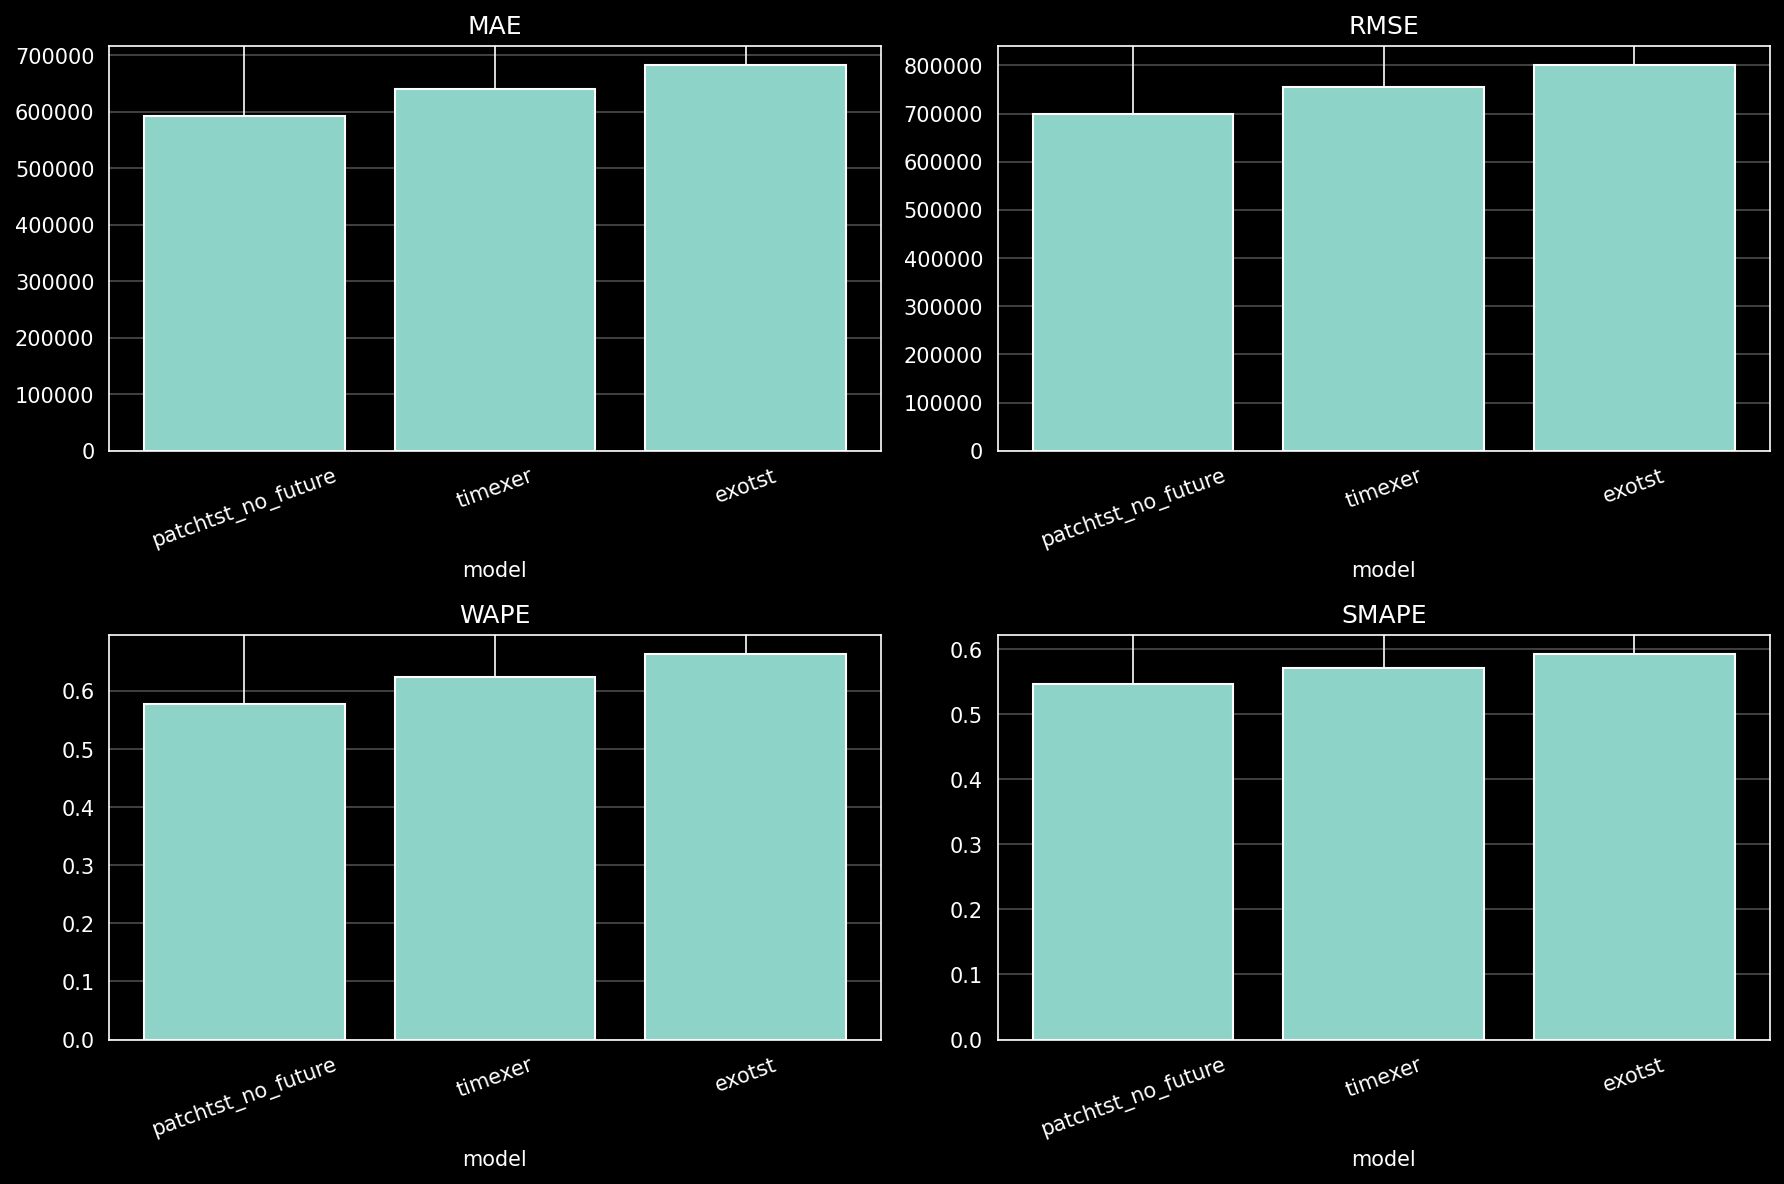

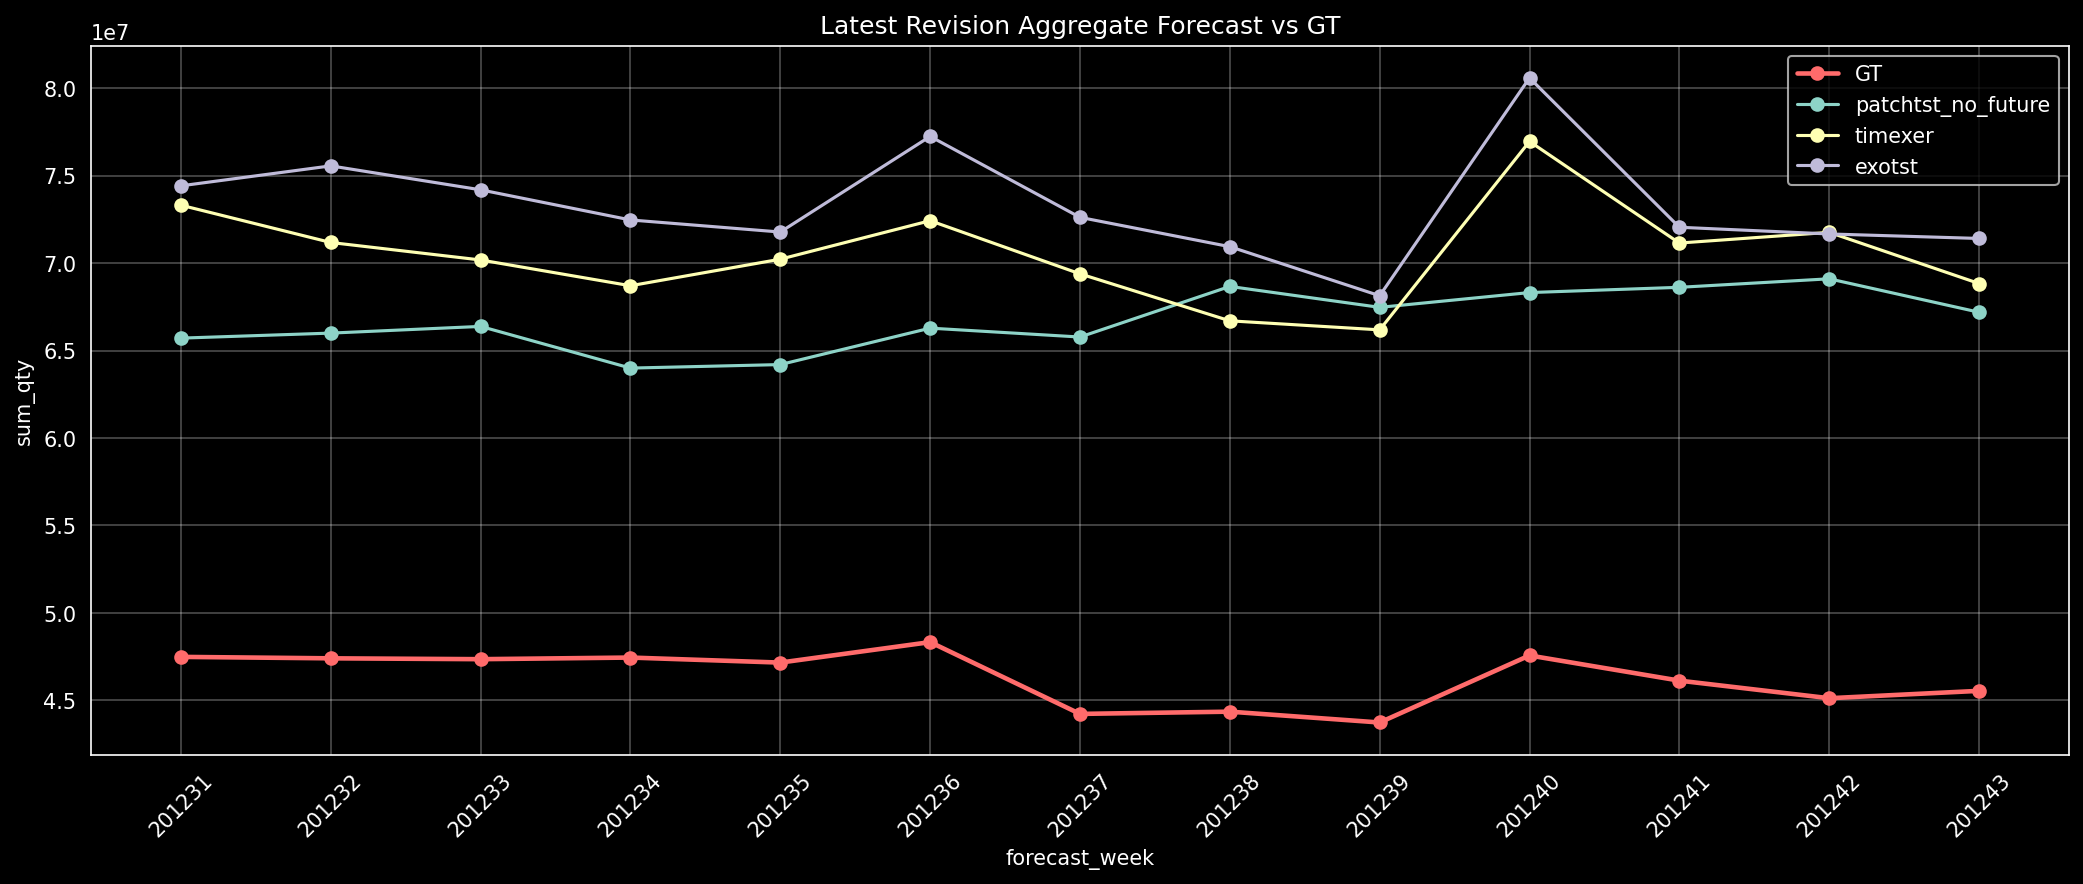

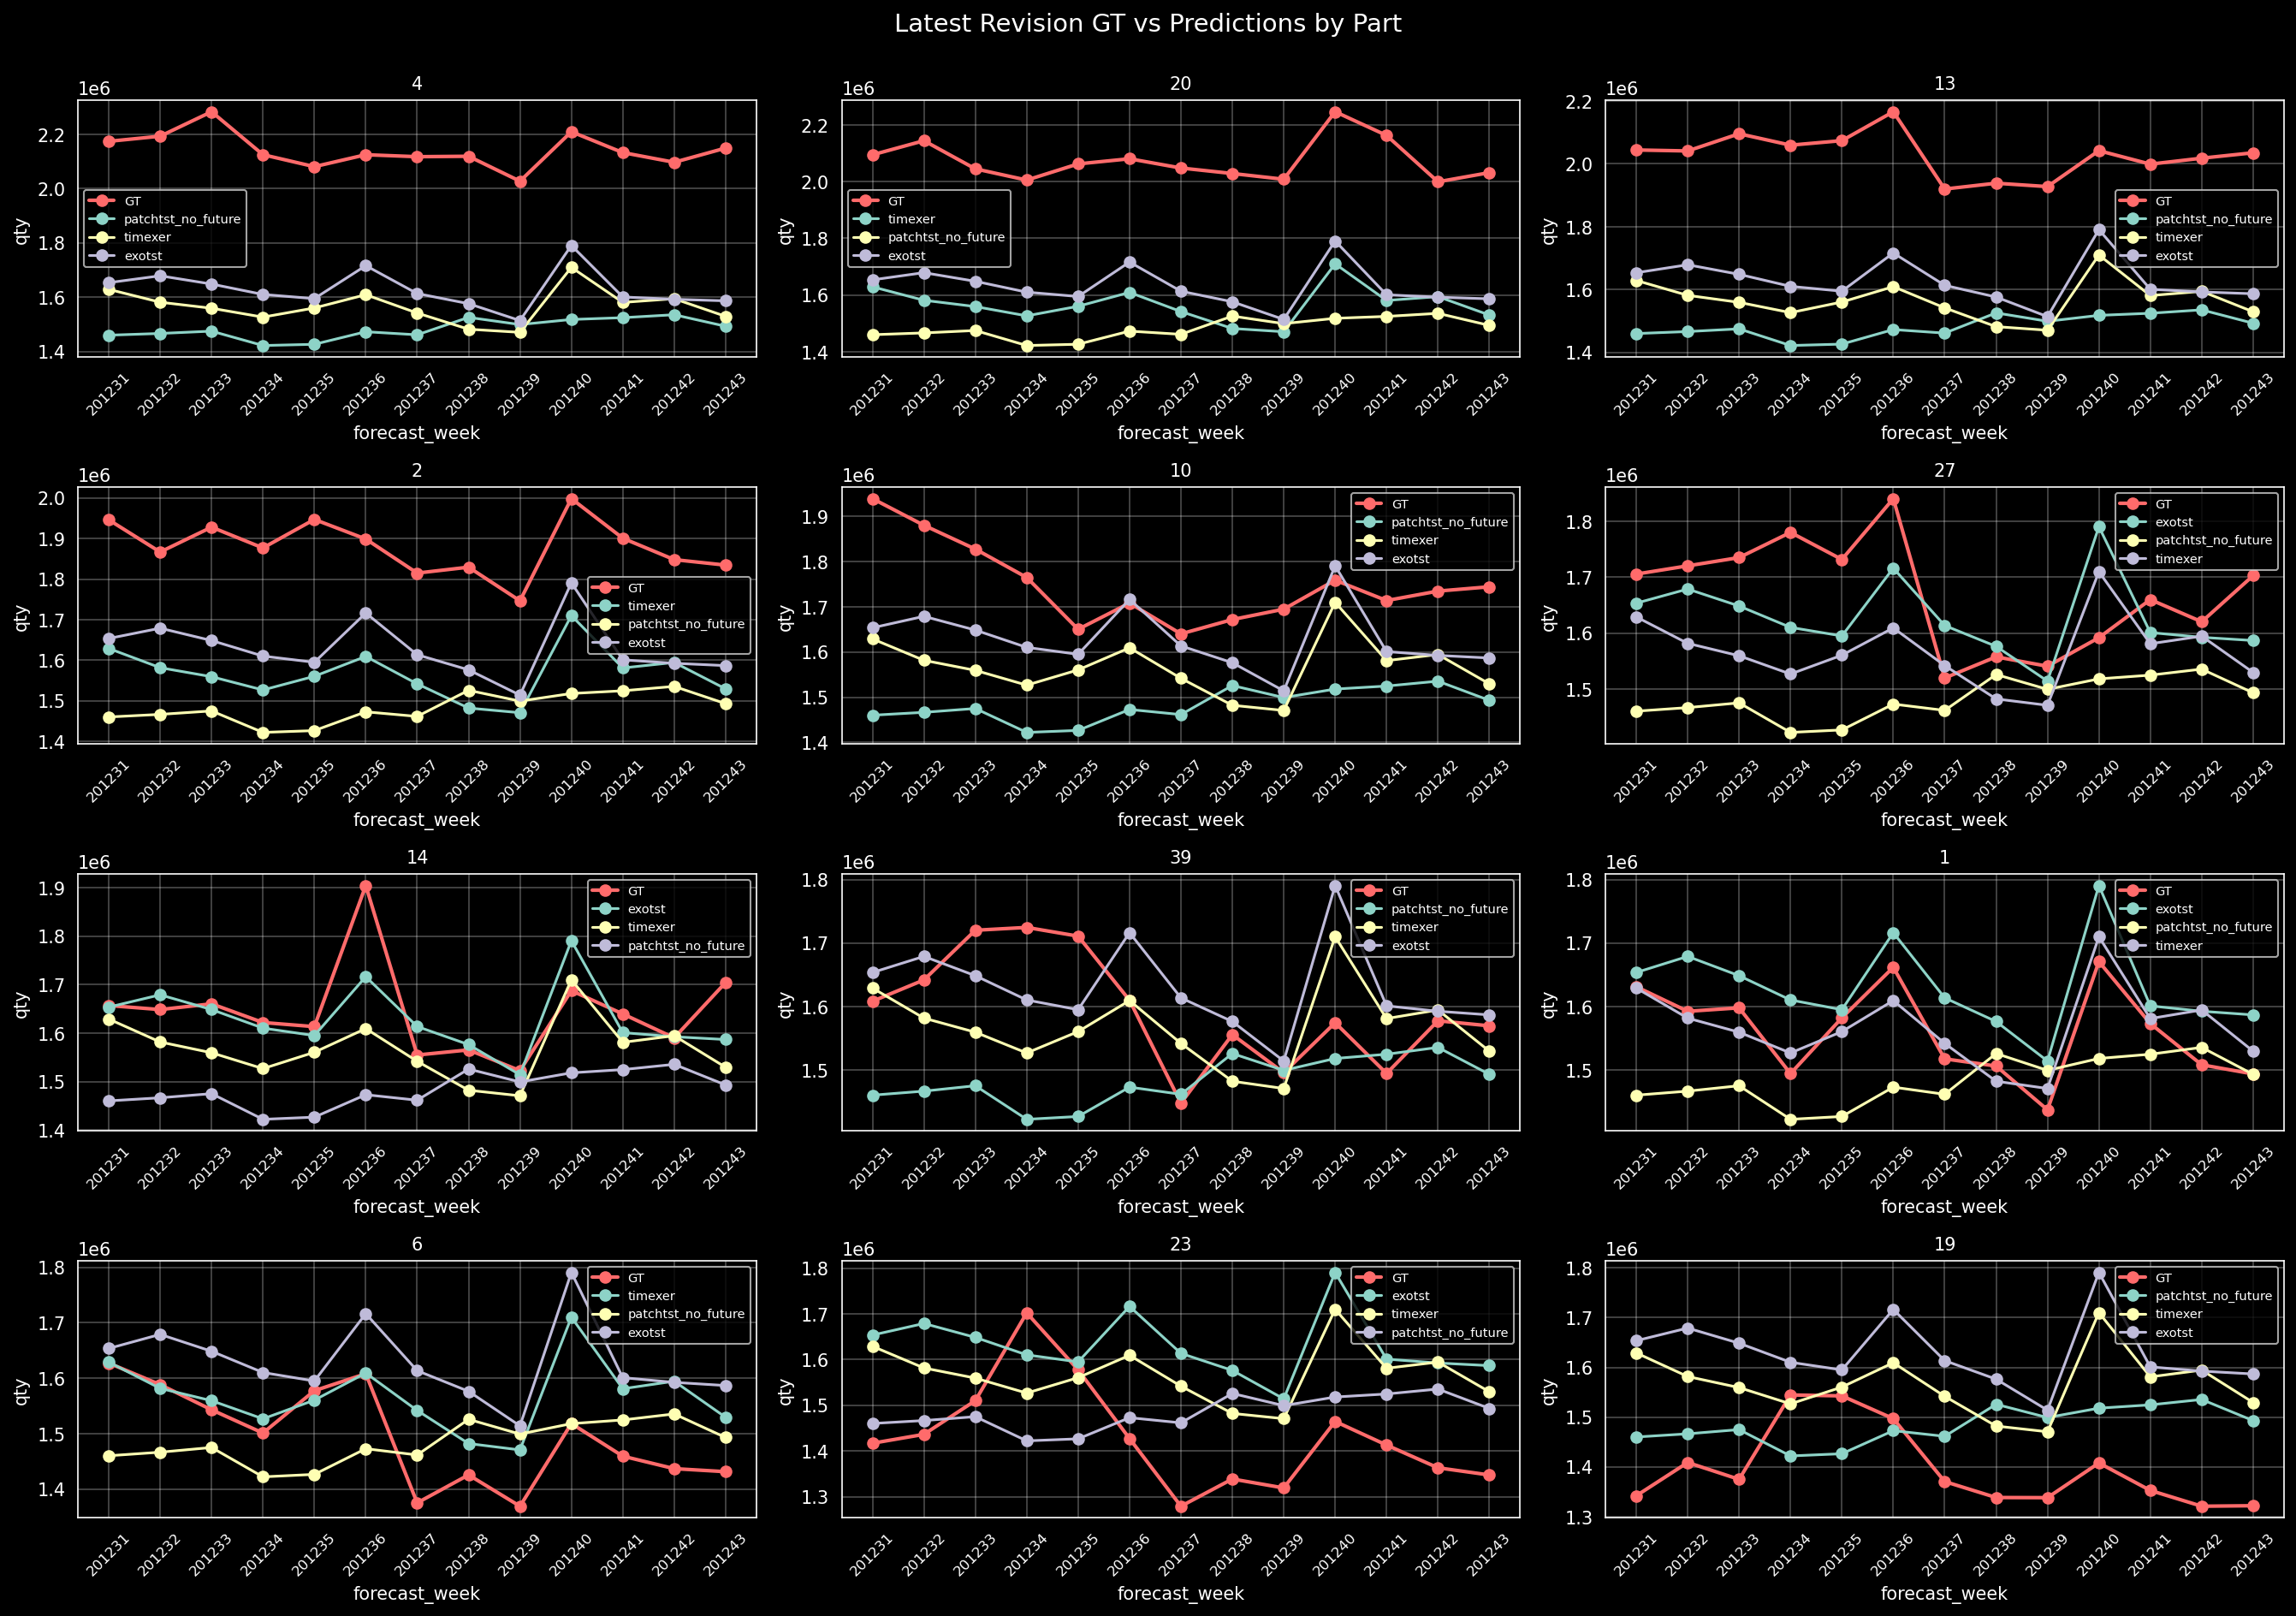

In [6]:

def summarize_scale(df: pl.DataFrame, group_cols: list[str]) -> pl.DataFrame:
    valid = df.filter(pl.col('actual').is_not_null())
    if valid.height == 0:
        return pl.DataFrame()
    return (
        valid.group_by(group_cols)
        .agg([
            pl.len().alias('n_rows'),
            pl.col('prediction').mean().alias('pred_mean'),
            pl.col('prediction').sum().alias('pred_sum'),
            pl.col('actual').mean().alias('actual_mean'),
            pl.col('actual').sum().alias('actual_sum'),
        ])
        .with_columns(
            pl.when(pl.col('actual_sum').abs() > 1e-12)
            .then(pl.col('pred_sum') / pl.col('actual_sum'))
            .otherwise(None)
            .alias('pred_to_actual_ratio')
        )
        .sort(group_cols)
    )



overall_df, horizon_df, latest_summary_df = compute_metric_tables(combined_forecast_df)
latest_df = select_latest_revision(combined_forecast_df.filter(pl.col('actual').is_not_null()))
scale_df = summarize_scale(latest_df, ['model_name'])
sampled_parts = select_plot_parts(latest_df, plot_part_count=plot_part_count)

metric_plot_path = run_root / 'walmart_metric_summary.png'
agg_plot_path = run_root / 'walmart_latest_revision_aggregate.png'
part_plot_path = run_root / 'walmart_latest_revision_parts.png'

plot_metric_summary(overall_df, metric_plot_path)
plot_latest_revision_aggregate(latest_df, agg_plot_path)
plot_latest_revision_part_grid(
    latest_df,
    sampled_parts=sampled_parts,
    save_path=part_plot_path,
    ncols=3,
)

print('overall metrics')
display(overall_df)
print('latest revision metrics')
display(latest_summary_df)
print('latest revision scale summary')
display(scale_df)

for p in [metric_plot_path, agg_plot_path, part_plot_path]:
    if p.exists():
        display(Image(filename=str(p)))



## PatchTST Diagnostics

이 섹션은 Walmart sanity check에서 기본 비교 모델인 `patchtst_no_future`를 기준으로,
왜 PatchTST가 future exo를 붙였을 때 불안정해지는지 추가로 좁히기 위한 진단입니다.

확인하는 것:
- `patchtst_no_future` raw prediction에 음수/극단치가 있는지
- 동일한 아키텍처에서 `future exogenous`를 다시 켜면 `patchtst_with_future`가 얼마나 불안정해지는지

해석 포인트:
- `raw unclipped`에서 음수 비율이 높고 clipped plot에서 0이 자주 나오면,
  현재 문제는 PatchTST point head 출력의 불안정성일 가능성이 큽니다.
- `patchtst_with_future`가 `patchtst_no_future`보다 훨씬 나쁘면,
  Walmart에서는 future exo handling이 핵심 원인이라는 강한 신호로 볼 수 있습니다.


In [ ]:

def attach_actuals_no_clip(
    forecast_df: pl.DataFrame,
    target_df: pl.DataFrame,
    *,
    id_col: str,
    date_col: str,
    y_col: str,
) -> pl.DataFrame:
    actual_df = target_df.select([
        pl.col(id_col).cast(pl.String).alias('part_no'),
        pl.col(date_col).cast(pl.Int64).alias('forecast_week'),
        pl.col(y_col).cast(pl.Float64).alias('actual'),
    ])
    return forecast_df.with_columns(pl.col('part_no').cast(pl.String)).join(
        actual_df,
        on=['part_no', 'forecast_week'],
        how='left',
    )


def build_patchtst_forecast_from_ckpt(
    ckpt_path: str,
    *,
    model_name: str,
    use_future_exogenous: bool,
    clip_negative: bool,
) -> pl.DataFrame:
    predictor = load_predictor(
        ckpt_path,
        device=device,
        forecaster_kwargs={
            'target_channel': 0,
            'fill_mode': 'copy_last',
            'use_winsor': False,
            'use_multi_guard': False,
        },
    )

    infer_req = build_walmart_data_request(
        df=infer_one_table,
        batch_size=infer_batch_size,
        shuffle=False,
        use_future_exogenous=use_future_exogenous,
    )
    infer_dm = build_datamodule(infer_req)
    infer_loader = infer_dm.get_inference_loader_at_plan(int(plan_week))

    forecast_df = make_point_forecast_result_table(
        inference_loader=infer_loader,
        predictor=predictor,
        model_name=model_name,
        plan_week=int(plan_week),
        horizon=horizon,
        device=device,
        max_parts=max_parts_per_plan,
    )
    if clip_negative:
        return attach_actuals(
            forecast_df,
            eval_target_df,
            id_col=ID_COL,
            date_col=DATE_COL,
            y_col=Y_COL,
        )
    return attach_actuals_no_clip(
        forecast_df,
        eval_target_df,
        id_col=ID_COL,
        date_col=DATE_COL,
        y_col=Y_COL,
    )


patch_spec = resolve_walmart_model_specs(['patchtst_no_future'])[0]
patch_train_result = results['patchtst_no_future']
patch_ckpt_path = patch_train_result.primary_ckpt_path or patch_train_result.ckpt_paths.get(patch_spec.request_key)
if not patch_ckpt_path:
    raise RuntimeError('Could not find checkpoint for patchtst_no_future')

print('patchtst_no_future checkpoint:', patch_ckpt_path)

patch_raw_df = build_patchtst_forecast_from_ckpt(
    patch_ckpt_path,
    model_name='patchtst_no_future_raw',
    use_future_exogenous=False,
    clip_negative=False,
)
patch_clipped_df = build_patchtst_forecast_from_ckpt(
    patch_ckpt_path,
    model_name='patchtst_no_future_clipped',
    use_future_exogenous=False,
    clip_negative=True,
)

raw_negative_summary = (
    patch_raw_df
    .with_columns((pl.col('prediction') < 0).alias('is_negative'))
    .group_by('horizon_step')
    .agg([
        pl.len().alias('n_rows'),
        pl.col('is_negative').sum().alias('n_negative'),
        pl.col('prediction').min().alias('pred_min'),
        pl.col('prediction').median().alias('pred_p50'),
        pl.col('prediction').max().alias('pred_max'),
    ])
    .with_columns((pl.col('n_negative') / pl.col('n_rows')).alias('negative_ratio'))
    .sort('horizon_step')
)

raw_global_summary = patch_raw_df.select([
    pl.len().alias('n_rows'),
    (pl.col('prediction') < 0).sum().alias('n_negative_total'),
    pl.col('prediction').min().alias('pred_min'),
    pl.col('prediction').median().alias('pred_p50'),
    pl.col('prediction').max().alias('pred_max'),
]).with_columns(
    (pl.col('n_negative_total') / pl.col('n_rows')).alias('negative_ratio_total')
)

print('patchtst_no_future raw prediction summary')
display(raw_global_summary)
print('patchtst_no_future raw prediction by horizon_step')
display(raw_negative_summary)

run_patchtst_with_future = True
patch_future_warmup_epochs = warmup_epochs
patch_future_spike_epochs = spike_epochs
patch_future_lr = lr

if run_patchtst_with_future:
    patch_future_dir = ensure_dir(run_root / 'patchtst_with_future')
    patch_future_train_req = build_walmart_data_request(
        df=train_one_table,
        batch_size=train_batch_size,
        shuffle=True,
        use_future_exogenous=True,
    )

    patch_future_result = train(
        TrainRequest(
            data=patch_future_train_req,
            freq=FREQ,
            use_exogenous_mode=True,
            use_past_exogenous=True,
            use_future_exogenous=True,
            models=['patchtst_base'],
            architecture=architecture,
            trainer=TrainerConfig(
                warmup_epochs=patch_future_warmup_epochs,
                spike_epochs=patch_future_spike_epochs,
                lr=patch_future_lr,
                use_intermittent=use_intermittent,
                val_use_weights=val_use_weights,
            ),
            ssl=SSLConfig(
                mode=effective_patchtst_ssl_mode,
                pretrain_epochs=ssl_pretrain_epochs,
                mask_ratio=ssl_mask_ratio,
                loss_type=ssl_loss_type,
            ),
            runtime=RuntimeConfig(device=device),
            artifacts=ArtifactConfig(
                save_dir=str(patch_future_dir),
                auto_save_dir=False,
            ),
        )
    )
    patch_future_ckpt = patch_future_result.primary_ckpt_path or patch_future_result.ckpt_paths.get('patchtst_base')
    if not patch_future_ckpt:
        raise RuntimeError('No checkpoint produced for patchtst_with_future')

    patch_future_df = build_patchtst_forecast_from_ckpt(
        patch_future_ckpt,
        model_name='patchtst_with_future',
        use_future_exogenous=True,
        clip_negative=True,
    )

    patch_compare_latest_df = pl.concat([
        select_latest_revision(patch_clipped_df.filter(pl.col('actual').is_not_null())),
        select_latest_revision(patch_future_df.filter(pl.col('actual').is_not_null())),
    ], how='vertical_relaxed')

    patch_compare_metrics = compute_metric_tables(
        pl.concat([patch_clipped_df, patch_future_df], how='vertical_relaxed')
    )[2].sort('model_name')
    patch_compare_scale = summarize_scale(patch_compare_latest_df, ['model_name'])

    print('patchtst no-future vs future-on latest metrics')
    display(patch_compare_metrics)
    print('patchtst no-future vs future-on scale summary')
    display(patch_compare_scale)

    compare_plot_path = run_root / 'walmart_patchtst_no_future_vs_future.png'

    actual_df = (
        patch_compare_latest_df
        .select(['part_no', 'forecast_week', 'actual'])
        .unique(subset=['part_no', 'forecast_week'])
        .group_by('forecast_week')
        .agg(pl.col('actual').sum().alias('actual_sum'))
        .sort('forecast_week')
    )
    x_actual = [str(v) for v in actual_df.get_column('forecast_week').to_list()]

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(x_actual, actual_df.get_column('actual_sum').to_list(), marker='o', linewidth=2.2, label='GT', color='#ff6b6b')

    for model_name in ['patchtst_no_future_clipped', 'patchtst_with_future']:
        pred_df = (
            patch_compare_latest_df
            .filter(pl.col('model_name') == model_name)
            .group_by('forecast_week')
            .agg(pl.col('prediction').sum().alias('pred_sum'))
            .sort('forecast_week')
        )
        ax.plot([str(v) for v in pred_df.get_column('forecast_week').to_list()], pred_df.get_column('pred_sum').to_list(), marker='o', label=model_name)

    ax.set_title('PatchTST diagnostic: no-future vs future-on')
    ax.set_xlabel('forecast_week')
    ax.set_ylabel('sum_qty')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig(compare_plot_path, dpi=150, bbox_inches='tight')
    plt.show()

    if compare_plot_path.exists():
        display(Image(filename=str(compare_plot_path)))

raw_vs_clipped_latest = pl.concat([
    select_latest_revision(patch_raw_df.filter(pl.col('actual').is_not_null())),
    select_latest_revision(patch_clipped_df.filter(pl.col('actual').is_not_null())),
], how='vertical_relaxed')

raw_vs_clipped_plot_path = run_root / 'walmart_patchtst_no_future_raw_vs_clipped.png'
actual_df = (
    raw_vs_clipped_latest
    .select(['part_no', 'forecast_week', 'actual'])
    .unique(subset=['part_no', 'forecast_week'])
    .group_by('forecast_week')
    .agg(pl.col('actual').sum().alias('actual_sum'))
    .sort('forecast_week')
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot([str(v) for v in actual_df.get_column('forecast_week').to_list()], actual_df.get_column('actual_sum').to_list(), marker='o', linewidth=2.2, label='GT', color='#ff6b6b')
for model_name in ['patchtst_no_future_raw', 'patchtst_no_future_clipped']:
    pred_df = (
        raw_vs_clipped_latest
        .filter(pl.col('model_name') == model_name)
        .group_by('forecast_week')
        .agg(pl.col('prediction').sum().alias('pred_sum'))
        .sort('forecast_week')
    )
    ax.plot([str(v) for v in pred_df.get_column('forecast_week').to_list()], pred_df.get_column('pred_sum').to_list(), marker='o', label=model_name)
ax.set_title('PatchTST diagnostic: no-future raw unclipped vs clipped')
ax.set_xlabel('forecast_week')
ax.set_ylabel('sum_qty')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(raw_vs_clipped_plot_path, dpi=150, bbox_inches='tight')
plt.show()

if raw_vs_clipped_plot_path.exists():
    display(Image(filename=str(raw_vs_clipped_plot_path)))



## Interpretation Guide

이 notebook의 목적은 **DSIO 문제의 원인이 모델 family 자체인지**를 분리하는 것입니다.

대략 이렇게 해석하면 됩니다.

- Walmart에서 세 모델 모두 `pred_to_actual_ratio`가 1 근처고 aggregate / part plot도 비교적 정상이다
  - global model family 자체는 작동한다고 볼 수 있음
  - DSIO 문제는 `small / erratic / high-obsolescence / decline` 같은 세그먼트 특성 쪽 가능성이 큼

- Walmart에서도 세 모델이 비슷하게 강한 overforecast / underforecast를 만든다
  - 모델/학습 정책(lookback, loss, stage schedule, calibration) 쪽을 더 강하게 의심해야 함

- Walmart에서는 한 모델만 정상이고 나머지 둘은 무너진다
  - 특정 architecture family가 현재 train policy와 더 잘/덜 맞는 것일 수 있음
